In [141]:
!pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 112.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 20.0.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


All features to be aggregated to party-election level  
  
Features to be used in regression:  
* Focus Level features (aggregated according to 3 supertopics)  
    * proportion of words       
* Stance features (included for a selected 3 subtopics)
    * net stance
* num debates (control)



---

Focus Level supertopics:
* economy
* Health
* social welfare  
  
Stance subtopics:
* Immigration
* Taxation
* Assistance for low income families

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV

In [4]:
# import the json files for turns, and copy the find_debates method

with open('../exploratory_analysis/grouped_sep_raw.json', 'r') as f:
    grouped_sep_raw_data = f.read()
grouped_sep_raw = json.loads(grouped_sep_raw_data)
with open('../exploratory_analysis/raw_debates.json', 'r') as f:
    raw_debates_data = f.read()
raw_debates=json.loads(raw_debates_data)    
with open('../exploratory_analysis/sep_raw_debates.json', 'r') as f:
    sep_raw_debates_data = f.read()
sep_raw_debates=json.loads(sep_raw_debates_data)
with open('../exploratory_analysis/sep_proc_debates.json', 'r') as f:
    sep_proc_debates_data = f.read()
sep_proc_debates = json.loads(sep_proc_debates_data)    
with open('../exploratory_analysis/grouped_sep_proc.json', 'r') as f:
    grouped_sep_proc_data = f.read()
grouped_sep_proc = json.loads(grouped_sep_proc_data)
with open('../exploratory_analysis/comb_raw_debates.json', 'r') as f:
    comb_raw_debates_data = f.read()
comb_raw_debates = json.loads(comb_raw_debates_data)
with open('../exploratory_analysis/comb_proc_debates.json', 'r') as f:
    comb_proc_debates_data = f.read()    
comb_proc_debates = json.loads(grouped_sep_raw_data)  

In [5]:
def find_debate(deb, structure, processing, grouping, person=None):  
    '''
    Easily find pre-processed debate transcript text in desired format
    deb - name of debate from options
    structure - 'separate'(each speaker) / 'combined'(all speakers)
    processing - 'proc'(pre-processing applied) / 'raw'(raw content)
    grouping - 'grouped'(all speaker turns combined) / 'turns'(separated into speaker turns)
    person - name of speaker in debate
    '''
    if structure == 'separate':
        #use sep and grouped dicts
        if grouping == 'turns':
            #use sep dicts
            if processing == 'proc':
                if person != None:                    
                    if person in participants[deb]:
                        return sep_proc_debates[deb][person]
                    else:                        
                        print("Invalid 'person' param. Non-participant in debate")
                        return
                else:                    
                    return sep_proc_debates[deb]
            elif processing == 'raw':
                if person != None:
                    if person in participants[deb]:
                        return sep_raw_debates[deb][person]
                    else:
                        print("Invalid 'person' param. Non-participant in debate")
                        return
                else:                    
                    return sep_raw_debates[deb]
            else:
                print("Invalid 'processing' param. Use options given in docstring")
                return
        elif grouping == 'grouped':
            #use grouped dicts
            if processing == 'proc':
                if person != None:
                    if person in participants[deb]:
                        return grouped_sep_proc[deb][person]
                    else:
                        print("Invalid 'person' param. Non-participant in debate")
                        return
                else:                    
                    return grouped_sep_proc[deb]
            elif processing == 'raw':
                if person != None:
                    if person in participants[deb]:
                        return grouped_sep_raw[deb][person]
                    else:
                        print("Invalid 'person' param. Non-participant in debate")
                        return
                else:                    
                    return grouped_sep_raw[deb]
            else:
                print("Invalid 'processing' param. Use options given in docstring")
                return
        else:
            print("Invalid 'grouping' param. Use options given in docstring")
            return
    elif structure == 'combined':
        #use comb dicts
        if processing == 'proc':
            return comb_proc_debates[deb]
        elif processing == 'raw':
            return comb_raw_debates[deb]
        else:
            print("Invalid 'processing' param. Use options given in docstring")
            return
    else:
        print("Invalid 'structure' param. Use options given in docstring")
        return
    

In [6]:
with open('../transcription/data/debate_participants.json', 'r') as f:
    participants_data = f.read()
participants = json.loads(participants_data)
participants

{'deb_2005_04_18': ['KENNEDY'],
 'deb_2005_04_20': ['BLAIR'],
 'deb_2005_04_22': ['HOWARD'],
 'deb_2005_04_28': ['KENNEDY', 'HOWARD', 'BLAIR'],
 'deb_2010_04_15': ['CLEGG', 'CAMERON', 'BROWN'],
 'deb_2010_04_22': ['CLEGG', 'CAMERON', 'BROWN'],
 'deb_2010_04_29': ['CAMERON', 'CLEGG', 'BROWN'],
 'deb_2015_03_26': ['CAMERON', 'MILIBAND'],
 'deb_2015_04_02': ['BENNETT',
  'CLEGG',
  'FARAGE',
  'MILIBAND',
  'WOOD',
  'STURGEON',
  'CAMERON'],
 'deb_2015_04_16': ['WOOD', 'FARAGE', 'MILIBAND', 'STURGEON', 'BENNETT'],
 'deb_2015_04_30': ['CAMERON', 'MILIBAND', 'CLEGG'],
 'deb_2017_05_18': ['LUCAS', 'WOOD', 'STURGEON', 'NUTTALL', 'FARRON'],
 'deb_2017_05_29': ['CORBYN', 'MAY'],
 'deb_2017_05_31': ['WOOD',
  'LUCAS',
  'RUDD',
  'CORBYN',
  'NUTTALL',
  'ROBERTSON',
  'FARRON'],
 'deb_2017_06_02': ['MAY', 'CORBYN'],
 'deb_2017_06_05': ['FARRON', 'STURGEON'],
 'deb_2017_06_06': ['ZAHAWI',
  'CHAMPION',
  'FORBES',
  'KURTEN',
  'PADDOCK',
  'ELIN',
  'BARTLEY'],
 'deb_2019_11_19': ['JOHNSON', '

In [7]:
deb_options = ['deb_2005_04_18',
 'deb_2005_04_20',
 'deb_2005_04_22',
 'deb_2005_04_28',
 'deb_2010_04_15',
 'deb_2010_04_22',
 'deb_2010_04_29',
 'deb_2015_03_26',
 'deb_2015_04_02',
 'deb_2015_04_16',
 'deb_2015_04_30',
 'deb_2017_05_18',
 'deb_2017_05_29',
 'deb_2017_05_31',
 'deb_2017_06_02',
 'deb_2017_06_05',
 'deb_2017_06_06',
 'deb_2019_11_19',
 'deb_2019_11_22',
 'deb_2019_11_28',
 'deb_2019_11_29',
 'deb_2019_12_01',
 'deb_2019_12_06',
 'deb_2019_12_09',
 'deb_2024_06_04',
 'deb_2024_06_04_01',
 'deb_2024_06_07',
 'deb_2024_06_12',
 'deb_2024_06_13',
 'deb_2024_06_18',
 'deb_2024_06_20',
 'deb_2024_06_24',
 'deb_2024_06_26']

In [8]:
len(deb_options)

33

In [9]:
# focus level

# import the focus_df
focus_df = pd.read_csv('../RQ1/Quantifying Focus/focus_df.csv', index_col=0)
focus_df

,debate,participant,topic,prop_turns,prop_words,avg_turn_length,turn_rank,word_rank,topic_title
0,deb_2005_04_18,KENNEDY,2000,0.113636,0.125430,34.000000,2,4,Government Operations
1,deb_2005_04_18,KENNEDY,2012,0.083333,0.087801,32.454545,3,10,"Political Parties, Campaigns, and Voter Regist..."
2,deb_2005_04_18,KENNEDY,100,0.128788,0.241515,57.764706,1,1,Macroeconomics
3,deb_2005_04_18,KENNEDY,107,0.068182,0.106493,48.111111,5,7,"Taxation, Tax policy, and Tax Reform"
4,deb_2005_04_18,KENNEDY,500,0.015152,0.033448,68.000000,19,21,Labour and Employment
...,...,...,...,...,...,...,...,...,...
3570,deb_2024_06_26,STARMER,1900,0.061224,0.056450,122.666667,14,22,International Affairs
3571,deb_2024_06_26,STARMER,1803,0.020408,0.035435,231.000000,27,36,"Export Promotion and Regulation, Export Credit..."
3572,deb_2024_06_26,STARMER,1910,0.061224,0.056450,122.666667,14,22,"Western Europe, Common Market Issues"
3573,deb_2024_06_26,STARMER,1920,0.020408,0.035435,231.000000,27,36,Middle East


In [10]:
# restrict to the supertopics of interest: 100, 300, 1300
focus_supertopics = [100, 300, 1300]
focus_feature_df = focus_df.loc[focus_df['topic'].isin(focus_supertopics)]
focus_feature_df

,debate,participant,topic,prop_turns,prop_words,avg_turn_length,turn_rank,word_rank,topic_title
2,deb_2005_04_18,KENNEDY,100,0.128788,0.241515,57.764706,1,1,Macroeconomics
10,deb_2005_04_18,KENNEDY,1300,0.053030,0.121987,70.857143,7,5,Social Welfare
19,deb_2005_04_18,KENNEDY,300,0.007576,0.007378,30.000000,24,36,Health
42,deb_2005_04_20,BLAIR,100,0.160714,0.298743,72.611111,3,1,Macroeconomics
53,deb_2005_04_20,BLAIR,1300,0.044643,0.080000,70.000000,8,8,Social Welfare
...,...,...,...,...,...,...,...,...,...
3504,deb_2024_06_26,SUNAK,100,0.540000,0.610734,150.037037,1,1,Macroeconomics
3509,deb_2024_06_26,SUNAK,1300,0.220000,0.307704,185.545455,5,5,Social Welfare
3537,deb_2024_06_26,STARMER,1300,0.122449,0.141126,153.333333,6,9,Social Welfare
3539,deb_2024_06_26,STARMER,100,0.387755,0.505752,173.526316,1,1,Macroeconomics


In [11]:
# restrict to the prop_words
focus_feature_df = focus_feature_df.drop(columns=['prop_turns', 'avg_turn_length', 'turn_rank', 'word_rank'])
focus_feature_df

,debate,participant,topic,prop_words,topic_title
2,deb_2005_04_18,KENNEDY,100,0.241515,Macroeconomics
10,deb_2005_04_18,KENNEDY,1300,0.121987,Social Welfare
19,deb_2005_04_18,KENNEDY,300,0.007378,Health
42,deb_2005_04_20,BLAIR,100,0.298743,Macroeconomics
53,deb_2005_04_20,BLAIR,1300,0.080000,Social Welfare
...,...,...,...,...,...
3504,deb_2024_06_26,SUNAK,100,0.610734,Macroeconomics
3509,deb_2024_06_26,SUNAK,1300,0.307704,Social Welfare
3537,deb_2024_06_26,STARMER,1300,0.141126,Social Welfare
3539,deb_2024_06_26,STARMER,100,0.505752,Macroeconomics


In [12]:
# title sufficient - no need for code
focus_feature_df = focus_feature_df.drop(columns=['topic'])
focus_feature_df

,debate,participant,prop_words,topic_title
2,deb_2005_04_18,KENNEDY,0.241515,Macroeconomics
10,deb_2005_04_18,KENNEDY,0.121987,Social Welfare
19,deb_2005_04_18,KENNEDY,0.007378,Health
42,deb_2005_04_20,BLAIR,0.298743,Macroeconomics
53,deb_2005_04_20,BLAIR,0.080000,Social Welfare
...,...,...,...,...
3504,deb_2024_06_26,SUNAK,0.610734,Macroeconomics
3509,deb_2024_06_26,SUNAK,0.307704,Social Welfare
3537,deb_2024_06_26,STARMER,0.141126,Social Welfare
3539,deb_2024_06_26,STARMER,0.505752,Macroeconomics


In [13]:
df_pivot = focus_feature_df.pivot(index=['debate', 'participant'], 
                    columns='topic_title', 
                    values='prop_words')

df_pivot.columns = [f"{col}_prop_words" for col in df_pivot.columns]

df_pivot = df_pivot.reset_index()
df_pivot

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social Welfare_prop_words
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163
...,...,...,...,...,...
121,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065
122,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590
123,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109
124,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126


In [14]:
nan_counts = df_pivot.isna().sum()
print(nan_counts)

debate                        0
participant                   0
Health_prop_words            39
Macroeconomics_prop_words     1
Social Welfare_prop_words     5
dtype: int64


In [15]:
df_pivot = df_pivot.fillna(0.0)
df_pivot

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social Welfare_prop_words
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163
...,...,...,...,...,...
121,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065
122,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590
123,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109
124,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126


In [16]:
focus_feature_df = df_pivot.copy()
focus_feature_df = focus_feature_df.rename(columns={'Social Welfare_prop_words': 'Social_Welfare_prop_words'})
focus_feature_df

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163
...,...,...,...,...,...
121,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065
122,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590
123,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109
124,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126


In [17]:
# before aggregating to party-election level, get the stance data

In [18]:
stance_train_df = pd.read_csv('../RQ1/Classifying Stance/train_stance.csv', index_col=0)
stance_train_df

,text,claim_labels,stance,confidence,topic_title
0,"Of course, we have to improve the system, but ...",230,against,0.853987,Immigration
1,I think this is partly what's been going wrong...,230,against,0.661541,Immigration
2,No. I want to be a member of the European Unio...,1910,support,0.827143,"Western Europe, Common Market Issues"
3,Well it depends whether you're talking about t...,107,neutral,0.590986,"Taxation, Tax policy, and Tax Reform"
4,But you are right when you say that you can't ...,230,against,0.695967,Immigration
...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,0.615345,"Taxation, Tax policy, and Tax Reform"
4118,"Terry, like so many people around the country,...",325,support,0.860713,Health Manpower and Training
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,0.951787,Veterans Issues
4120,There are lots of people who go for private he...,108,support,0.614357,"Industrial Policy, Privatisation, Nationalisation"


In [19]:
stance_test_df = pd.read_csv('../RQ1/Classifying Stance/test_stance.csv', index_col=0)
stance_test_df

,ID,text,claim_labels,stance,topic_title
0,0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention
1,1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform"
2,1,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families
3,1,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education
4,1,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students
...,...,...,...,...,...
534,2601,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination
535,2601,"Well, I share the frustration of both our ques...",230,neutral,Immigration
536,3070,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety
537,3356,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...


In [20]:
stance_train_df = stance_train_df.drop(columns=['confidence'])
stance_train_df

,text,claim_labels,stance,topic_title
0,"Of course, we have to improve the system, but ...",230,against,Immigration
1,I think this is partly what's been going wrong...,230,against,Immigration
2,No. I want to be a member of the European Unio...,1910,support,"Western Europe, Common Market Issues"
3,Well it depends whether you're talking about t...,107,neutral,"Taxation, Tax policy, and Tax Reform"
4,But you are right when you say that you can't ...,230,against,Immigration
...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,"Taxation, Tax policy, and Tax Reform"
4118,"Terry, like so many people around the country,...",325,support,Health Manpower and Training
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,Veterans Issues
4120,There are lots of people who go for private he...,108,support,"Industrial Policy, Privatisation, Nationalisation"


In [21]:
stance_test_df = stance_test_df.drop(columns=['ID'])
stance_test_df

,text,claim_labels,stance,topic_title
0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention
1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform"
2,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families
3,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education
4,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students
...,...,...,...,...
534,"Well, I share the frustration of both our ques...",202,support,Gender and Sexual Orientation Discrimination
535,"Well, I share the frustration of both our ques...",230,neutral,Immigration
536,You're saying people voted for 10% tariffs on ...,1006,support,Truck and Automobile Transportation and Safety
537,I think this question of enthusiasm is really ...,2032,support,Prime Ministerial or Ministerial Scandals and ...


In [22]:
stance_df = pd.concat([stance_test_df, stance_train_df], axis=0)
stance_df

,text,claim_labels,stance,topic_title
0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention
1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform"
2,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families
3,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education
4,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students
...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,"Taxation, Tax policy, and Tax Reform"
4118,"Terry, like so many people around the country,...",325,support,Health Manpower and Training
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,Veterans Issues
4120,There are lots of people who go for private he...,108,support,"Industrial Policy, Privatisation, Nationalisation"


In [23]:
tmp_df = stance_df.copy()
tmp_df['debate'] = tmp_df['participant'] = np.nan
tmp_df

,text,claim_labels,stance,topic_title,debate,participant
0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention,NaN,NaN
1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform",NaN,NaN
2,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families,NaN,NaN
3,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education,NaN,NaN
4,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students,NaN,NaN
...,...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,"Taxation, Tax policy, and Tax Reform",NaN,NaN
4118,"Terry, like so many people around the country,...",325,support,Health Manpower and Training,NaN,NaN
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,Veterans Issues,NaN,NaN
4120,There are lots of people who go for private he...,108,support,"Industrial Policy, Privatisation, Nationalisation",NaN,NaN


In [24]:
# assign debate and participant to text

lookup = {}
for deb in deb_options:
    for candidate in participants[deb]:
        turns = find_debate(deb, 'separate', 'raw', 'turns', candidate)
        for turn in turns:
            lookup[turn.strip()] = {'deb': deb, 'part': candidate}

def assign_info(text):
    clean_text = str(text).strip()
    match = lookup.get(clean_text)
    if match:
        return pd.Series([match['deb'], match['part']])
    print("No match for\n", text)
    return pd.Series([np.nan, np.nan])

tmp_df[['debate', 'participant']] = tmp_df['text'].apply(assign_info)

No match for
 Greens holding you to account on that in the Parliament. Doing a good job.


In [25]:
tmp_df

,text,claim_labels,stance,topic_title,debate,participant
0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention,deb_2024_06_18,TICE
1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform",deb_2010_04_29,CLEGG
2,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families,deb_2010_04_29,CLEGG
3,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education,deb_2010_04_29,CLEGG
4,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students,deb_2010_04_29,CLEGG
...,...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,"Taxation, Tax policy, and Tax Reform",deb_2015_04_02,MILIBAND
4118,"Terry, like so many people around the country,...",325,support,Health Manpower and Training,deb_2015_04_02,MILIBAND
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,Veterans Issues,deb_2024_06_12,SUNAK
4120,There are lots of people who go for private he...,108,support,"Industrial Policy, Privatisation, Nationalisation",deb_2005_04_28,HOWARD


In [26]:
tmp_df = tmp_df.loc[~(tmp_df['text']=="Greens holding you to account on that in the Parliament. Doing a good job.")]

In [27]:
stance_df = tmp_df.copy()

In [28]:
stance_df = stance_df.rename(columns={'claim_labels':'topic'})
stance_df

,text,topic,stance,topic_title,debate,participant
0,"So knife crime's going to go up, because the e...",1211,support,Riots and Crime Prevention,deb_2024_06_18,TICE
1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform",deb_2010_04_29,CLEGG
2,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families,deb_2010_04_29,CLEGG
3,Of course Gordon Brown's right to say there's ...,602,support,Elementary and Secondary Education,deb_2010_04_29,CLEGG
4,Of course Gordon Brown's right to say there's ...,603,support,Education of Underprivileged Students,deb_2010_04_29,CLEGG
...,...,...,...,...,...,...
4117,"Terry, like so many people around the country,...",107,support,"Taxation, Tax policy, and Tax Reform",deb_2015_04_02,MILIBAND
4118,"Terry, like so many people around the country,...",325,support,Health Manpower and Training,deb_2015_04_02,MILIBAND
4119,"Yeah, I was incredibly sad to have caused peop...",1609,support,Veterans Issues,deb_2024_06_12,SUNAK
4120,There are lots of people who go for private he...,108,support,"Industrial Policy, Privatisation, Nationalisation",deb_2005_04_28,HOWARD


In [29]:
# keep only the subtopics to be used in regression
stance_subtopics = [107, 230, 1302]
stance_feature_df = stance_df.loc[stance_df['topic'].isin(stance_subtopics)]
stance_feature_df

,text,topic,stance,topic_title,debate,participant
1,Of course Gordon Brown's right to say there's ...,107,against,"Taxation, Tax policy, and Tax Reform",deb_2010_04_29,CLEGG
2,Of course Gordon Brown's right to say there's ...,1302,support,Poverty and Assistance for Low-Income Families,deb_2010_04_29,CLEGG
6,"I tell you how we pay for it. We would, for in...",107,against,"Taxation, Tax policy, and Tax Reform",deb_2010_04_15,CLEGG
14,Let me perhaps draw out one of them. David Cam...,1302,against,Poverty and Assistance for Low-Income Families,deb_2010_04_29,CLEGG
15,Let me perhaps draw out one of them. David Cam...,107,against,"Taxation, Tax policy, and Tax Reform",deb_2010_04_29,CLEGG
...,...,...,...,...,...,...
4110,I could stand here on this stage tonight becau...,1302,support,Poverty and Assistance for Low-Income Families,deb_2019_12_01,PRICE
4111,Processed? They're not... These claims are not...,230,neutral,Immigration,deb_2024_06_26,STARMER
4112,Processed? They're not... These claims are not...,1302,support,Poverty and Assistance for Low-Income Families,deb_2024_06_26,STARMER
4117,"Terry, like so many people around the country,...",107,support,"Taxation, Tax policy, and Tax Reform",deb_2015_04_02,MILIBAND


In [30]:
tmp_df = stance_feature_df.copy()

In [31]:
counts = tmp_df.groupby(['debate', 'participant', 'topic_title', 'stance']).size().unstack(fill_value=0)
for col in ['support', 'against', 'neutral']:
    if col not in counts.columns:
        counts[col] = 0

counts['total'] = counts['support'] + counts['against'] + counts['neutral']
counts

stance                                                                     against  \
debate         participant topic_title                                               
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families        0   
                           Taxation, Tax policy, and Tax Reform                  0   
deb_2005_04_20 BLAIR       Immigration                                          10   
                           Poverty and Assistance for Low-Income Families        0   
                           Taxation, Tax policy, and Tax Reform                  3   
...                                                                            ...   
deb_2024_06_26 STARMER     Poverty and Assistance for Low-Income Families        0   
                           Taxation, Tax policy, and Tax Reform                  0   
               SUNAK       Immigration                                          13   
                           Poverty and Assistance for Low-Income Families        3   
                           Taxation, Tax policy, and Tax Reform                  9   

stance                                                                     against   \
debate         participant topic_title                                                
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   0   
deb_2005_04_20 BLAIR       Immigration                                            0   
                           Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   0   
...                                                                             ...   
deb_2024_06_26 STARMER     Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   0   
               SUNAK       Immigration                                            1   
                           Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   3   

stance                                                                     against    \
debate         participant topic_title                                                 
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   
deb_2005_04_20 BLAIR       Immigration                                             0   
                           Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   
...                                                                              ...   
deb_2024_06_26 STARMER     Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   
               SUNAK       Immigration                                             0   
                           Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   

stance                                                                     against                           \
debate         participant topic_title                                                                        
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families                                 0   
                           Taxation, Tax policy, and Tax Reform                                           0   
deb_2005_04_20 BLAIR       Immigration                                                                    0   
                           Poverty and Assistance

In [32]:
counts['net_stance'] = (counts['support'] - counts['against']) / counts['total']
counts

stance                                                                     against  \
debate         participant topic_title                                               
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families        0   
                           Taxation, Tax policy, and Tax Reform                  0   
deb_2005_04_20 BLAIR       Immigration                                          10   
                           Poverty and Assistance for Low-Income Families        0   
                           Taxation, Tax policy, and Tax Reform                  3   
...                                                                            ...   
deb_2024_06_26 STARMER     Poverty and Assistance for Low-Income Families        0   
                           Taxation, Tax policy, and Tax Reform                  0   
               SUNAK       Immigration                                          13   
                           Poverty and Assistance for Low-Income Families        3   
                           Taxation, Tax policy, and Tax Reform                  9   

stance                                                                     against   \
debate         participant topic_title                                                
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   0   
deb_2005_04_20 BLAIR       Immigration                                            0   
                           Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   0   
...                                                                             ...   
deb_2024_06_26 STARMER     Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   0   
               SUNAK       Immigration                                            1   
                           Poverty and Assistance for Low-Income Families         0   
                           Taxation, Tax policy, and Tax Reform                   3   

stance                                                                     against    \
debate         participant topic_title                                                 
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   
deb_2005_04_20 BLAIR       Immigration                                             0   
                           Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   
...                                                                              ...   
deb_2024_06_26 STARMER     Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   
               SUNAK       Immigration                                             0   
                           Poverty and Assistance for Low-Income Families          0   
                           Taxation, Tax policy, and Tax Reform                    0   

stance                                                                     against                           \
debate         participant topic_title                                                                        
deb_2005_04_18 KENNEDY     Poverty and Assistance for Low-Income Families                                 0   
                           Taxation, Tax policy, and Tax Reform                                           0   
deb_2005_04_20 BLAIR       Immigration                                                                    0   
                           Poverty and Assistance

In [33]:
final_df = counts['net_stance'].unstack(fill_value=0)

final_df.columns = [f"{col}_net_stance" for col in final_df.columns]

final_df = final_df.reset_index()
final_df

,debate,participant,Immigration_net_stance,Poverty and Assistance for Low-Income Families_net_stance,"Taxation, Tax policy, and Tax Reform_net_stance"
0,deb_2005_04_18,KENNEDY,0.000000,0.5,1.000000
1,deb_2005_04_20,BLAIR,-0.833333,1.0,-1.000000
2,deb_2005_04_22,HOWARD,-0.500000,1.0,-0.384615
3,deb_2005_04_28,BLAIR,0.000000,1.0,0.000000
4,deb_2005_04_28,HOWARD,0.000000,1.0,0.250000
...,...,...,...,...,...
117,deb_2024_06_20,SWINNEY,0.000000,1.0,0.000000
118,deb_2024_06_24,STARMER,-1.000000,0.0,0.000000
119,deb_2024_06_24,SUNAK,-1.000000,0.0,-1.000000
120,deb_2024_06_26,STARMER,-0.750000,1.0,1.000000


In [34]:
stance_feature_df = final_df.copy()

In [35]:
stance_feature_df = stance_feature_df.rename(columns={'Poverty and Assistance for Low-Income Families_net_stance':'Low_Income_Assistance_net_stance',
                                                     'Taxation, Tax policy, and Tax Reform_net_stance':'Taxation_net_stance'})
stance_feature_df

,debate,participant,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
0,deb_2005_04_18,KENNEDY,0.000000,0.5,1.000000
1,deb_2005_04_20,BLAIR,-0.833333,1.0,-1.000000
2,deb_2005_04_22,HOWARD,-0.500000,1.0,-0.384615
3,deb_2005_04_28,BLAIR,0.000000,1.0,0.000000
4,deb_2005_04_28,HOWARD,0.000000,1.0,0.250000
...,...,...,...,...,...
117,deb_2024_06_20,SWINNEY,0.000000,1.0,0.000000
118,deb_2024_06_24,STARMER,-1.000000,0.0,0.000000
119,deb_2024_06_24,SUNAK,-1.000000,0.0,-1.000000
120,deb_2024_06_26,STARMER,-0.750000,1.0,1.000000


In [36]:
focus_feature_df

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163
...,...,...,...,...,...
121,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065
122,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590
123,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109
124,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126


In [37]:
comparison = pd.merge(focus_feature_df, stance_feature_df, on=['debate', 'participant'], how='left', indicator=True)

# 2. Filter for rows that only exist in the left (df2)
missing_in_df1 = comparison[comparison['_merge'] == 'left_only']

# 3. Clean up and see the result
result = missing_in_df1[['debate', 'participant']]
print(result)

            debate participant
45  deb_2017_05_31        WOOD
52  deb_2017_06_06        ELIN
63  deb_2019_11_28       BERRY
73  deb_2019_11_29        TICE


In [38]:
focus_feature_df = focus_feature_df.loc[~((focus_feature_df['debate']=='deb_2017_05_31')&(focus_feature_df['participant']=='WOOD'))]

In [39]:
focus_feature_df = focus_feature_df.loc[~((focus_feature_df['debate']=='deb_2017_06_06')&(focus_feature_df['participant']=='ELIN'))]

In [40]:
focus_feature_df = focus_feature_df.loc[~((focus_feature_df['debate']=='deb_2019_11_28')&(focus_feature_df['participant']=='BERRY'))]

In [41]:
focus_feature_df = focus_feature_df.loc[~((focus_feature_df['debate']=='deb_2019_11_29')&(focus_feature_df['participant']=='TICE'))]

In [42]:
focus_feature_df

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163
...,...,...,...,...,...
121,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065
122,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590
123,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109
124,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126


In [43]:
feature_df = pd.merge(focus_feature_df, stance_feature_df, on=['debate', 'participant'], how='left', indicator=False)
feature_df

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987,0.000000,0.5,1.000000
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000,-0.833333,1.0,-1.000000
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328,-0.500000,1.0,-0.384615
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011,0.000000,1.0,0.000000
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163,0.000000,1.0,0.250000
...,...,...,...,...,...,...,...,...
117,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065,0.000000,1.0,0.000000
118,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590,-1.000000,0.0,0.000000
119,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109,-1.000000,0.0,-1.000000
120,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126,-0.750000,1.0,1.000000


In [44]:
tmp_df = feature_df.copy()

In [45]:
# aggregating to the party-election level

# include the party for each participant

conditions = [
    # 2005
    (tmp_df['debate'].str.contains('2005', na=False)) & (tmp_df['participant'] == 'KENNEDY'),
    (tmp_df['debate'].str.contains('2005', na=False)) & (tmp_df['participant'] == 'BLAIR'),
    (tmp_df['debate'].str.contains('2005', na=False)) & (tmp_df['participant'] == 'HOWARD'),
    
    # 2010
    (tmp_df['debate'].str.contains('2010', na=False)) & (tmp_df['participant'] == 'CLEGG'),
    (tmp_df['debate'].str.contains('2010', na=False)) & (tmp_df['participant'] == 'CAMERON'),
    (tmp_df['debate'].str.contains('2010', na=False)) & (tmp_df['participant'] == 'BROWN'),

    # 2015
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'CAMERON'),
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'MILIBAND'),
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'BENNETT'),
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'CLEGG'),
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'FARAGE'),
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'WOOD'),
    (tmp_df['debate'].str.contains('2015', na=False)) & (tmp_df['participant'] == 'STURGEON'),

    # 2017
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'LUCAS'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'WOOD'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'STURGEON'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'NUTTALL'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'FARRON'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'CORBYN'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'MAY'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'RUDD'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'ROBERTSON'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'ZAHAWI'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'CHAMPION'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'FORBES'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'KURTEN'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'PADDOCK'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'ELIN'),
    (tmp_df['debate'].str.contains('2017', na=False)) & (tmp_df['participant'] == 'BARTLEY'),

    # 2019
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'JOHNSON'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'CORBYN'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'STURGEON'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'SWINSON'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'BERRY'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'PRICE'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'TICE'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'SUNAK'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'LONG-BAILEY'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'LUCAS'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'FARAGE'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'BURGON'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'JENRICK'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'RAYNER'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'YOUSAF'),
    (tmp_df['debate'].str.contains('2019', na=False)) & (tmp_df['participant'] == 'BARTLEY'),

    # 2024
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'SUNAK'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'STARMER'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'DAVEY'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'FLYNN'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'TICE'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'RAMSAY'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'MORDAUNT'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'FARAGE'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'RAYNER'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'IORWERTH'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'DENYER'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'COOPER'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'PHILP'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'THOMAS-SYMONDS'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'BROWN'),
    (tmp_df['debate'].str.contains('2024', na=False)) & (tmp_df['participant'] == 'SWINNEY')
]



In [46]:
parties = [
    # 2005
    'Liberal Democrat',   # KENNEDY
    'Labour',             # BLAIR
    'Conservative',       # HOWARD
    
    # 2010
    'Liberal Democrat',   # CLEGG
    'Conservative',       # CAMERON
    'Labour',             # BROWN

    # 2015
    'Conservative',       # CAMERON
    'Labour',             # MILIBAND
    'Green',              # BENNETT
    'Liberal Democrat',   # CLEGG
    'UKIP',               # FARAGE
    'Plaid Cymru',        # WOOD
    'SNP',                # STURGEON

    # 2017
    'Green',              # LUCAS
    'Plaid Cymru',        # WOOD
    'SNP',                # STURGEON
    'UKIP',               # NUTTALL
    'Liberal Democrat',   # FARRON
    'Labour',             # CORBYN
    'Conservative',       # MAY
    'Conservative',       # RUDD
    'SNP',                # ROBERTSON
    'Conservative',       # ZAHAWI
    'Labour',             # CHAMPION
    'SNP',                # FORBES
    'UKIP',               # KURTEN
    'Conservative',       # PADDOCK
    'Conservative',       # ELIN
    'Green',              # BARTLEY

    # 2019
    'Conservative',       # JOHNSON
    'Labour',             # CORBYN
    'SNP',                # STURGEON
    'Liberal Democrat',   # SWINSON
    'Green',              # BERRY
    'Plaid Cymru',        # PRICE
    'Brexit Party',       # TICE
    'Conservative',       # SUNAK
    'Labour',             # LONG-BAILEY
    'Green',              # LUCAS
    'Brexit Party',       # FARAGE
    'Labour',             # BURGON
    'Conservative',       # JENRICK
    'Labour',             # RAYNER
    'SNP',                # YOUSAF
    'Green',              # BARTLEY

    # 2024
    'Conservative',       # SUNAK
    'Labour',             # STARMER
    'Liberal Democrat',   # DAVEY
    'SNP',                # FLYNN
    'Reform UK',          # TICE
    'Green',              # RAMSAY
    'Conservative',       # MORDAUNT
    'Reform UK',          # FARAGE
    'Labour',             # RAYNER
    'Plaid Cymru',        # IORWERTH
    'Green',              # DENYER
    'Labour',             # COOPER
    'Conservative',       # PHILP
    'Labour',             # THOMAS-SYMONDS
    'SNP',                # BROWN
    'SNP',                # SWINNEY
]

years = [
    # 2005
    '2005', '2005', '2005',
    
    # 2010
    '2010', '2010', '2010',

    # 2015
    '2015', '2015', '2015', '2015', '2015', '2015', '2015',

    # 2017
    '2017', '2017', '2017', '2017', '2017', '2017', '2017', 
    '2017', '2017', '2017', '2017', '2017', '2017', '2017', 
    '2017', '2017',

    # 2019
    '2019', '2019', '2019', '2019', '2019', '2019', '2019', 
    '2019', '2019', '2019', '2019', '2019', '2019', '2019', 
    '2019', '2019',

    # 2024
    '2024', '2024', '2024', '2024', '2024', '2024', '2024', 
    '2024', '2024', '2024', '2024', '2024', '2024', '2024', 
    '2024', '2024'
]




In [47]:
tmp_df['party'] = np.select(conditions, parties, default=None)
tmp_df['year'] = np.select(conditions, years, default=None)
tmp_df

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance,party,year
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987,0.000000,0.5,1.000000,Liberal Democrat,2005
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000,-0.833333,1.0,-1.000000,Labour,2005
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328,-0.500000,1.0,-0.384615,Conservative,2005
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011,0.000000,1.0,0.000000,Labour,2005
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163,0.000000,1.0,0.250000,Conservative,2005
...,...,...,...,...,...,...,...,...,...,...
117,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065,0.000000,1.0,0.000000,SNP,2024
118,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590,-1.000000,0.0,0.000000,Labour,2024
119,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109,-1.000000,0.0,-1.000000,Conservative,2024
120,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126,-0.750000,1.0,1.000000,Labour,2024


In [48]:
nan_counts = tmp_df.isna().sum()
print(nan_counts)

debate                              0
participant                         0
Health_prop_words                   0
Macroeconomics_prop_words           0
Social_Welfare_prop_words           0
Immigration_net_stance              0
Low_Income_Assistance_net_stance    0
Taxation_net_stance                 0
party                               0
year                                0
dtype: int64


In [49]:
feature_df = tmp_df.copy()

In [50]:
tmp_df = feature_df.copy()

In [51]:
tmp_df['no_debates'] = tmp_df.groupby(['party', 'year'])['debate'].transform('count')
tmp_df

,debate,participant,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance,party,year,no_debates
0,deb_2005_04_18,KENNEDY,0.007378,0.241515,0.121987,0.000000,0.5,1.000000,Liberal Democrat,2005,2
1,deb_2005_04_20,BLAIR,0.083886,0.298743,0.080000,-0.833333,1.0,-1.000000,Labour,2005,2
2,deb_2005_04_22,HOWARD,0.121007,0.488184,0.050328,-0.500000,1.0,-0.384615,Conservative,2005,2
3,deb_2005_04_28,BLAIR,0.231001,0.272977,0.048011,0.000000,1.0,0.000000,Labour,2005,2
4,deb_2005_04_28,HOWARD,0.128281,0.293519,0.085163,0.000000,1.0,0.250000,Conservative,2005,2
...,...,...,...,...,...,...,...,...,...,...,...
117,deb_2024_06_20,SWINNEY,0.140950,0.333531,0.194065,0.000000,1.0,0.000000,SNP,2024,5
118,deb_2024_06_24,STARMER,0.216751,0.089957,0.101590,-1.000000,0.0,0.000000,Labour,2024,10
119,deb_2024_06_24,SUNAK,0.152315,0.573670,0.055109,-1.000000,0.0,-1.000000,Conservative,2024,8
120,deb_2024_06_26,STARMER,0.083909,0.505752,0.141126,-0.750000,1.0,1.000000,Labour,2024,10


In [52]:
tmp_df = tmp_df.drop(columns=['debate', 'participant'])
tmp_df

,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance,party,year,no_debates
0,0.007378,0.241515,0.121987,0.000000,0.5,1.000000,Liberal Democrat,2005,2
1,0.083886,0.298743,0.080000,-0.833333,1.0,-1.000000,Labour,2005,2
2,0.121007,0.488184,0.050328,-0.500000,1.0,-0.384615,Conservative,2005,2
3,0.231001,0.272977,0.048011,0.000000,1.0,0.000000,Labour,2005,2
4,0.128281,0.293519,0.085163,0.000000,1.0,0.250000,Conservative,2005,2
...,...,...,...,...,...,...,...,...,...
117,0.140950,0.333531,0.194065,0.000000,1.0,0.000000,SNP,2024,5
118,0.216751,0.089957,0.101590,-1.000000,0.0,0.000000,Labour,2024,10
119,0.152315,0.573670,0.055109,-1.000000,0.0,-1.000000,Conservative,2024,8
120,0.083909,0.505752,0.141126,-0.750000,1.0,1.000000,Labour,2024,10


In [53]:
cols_to_move = ['party', 'year', 'no_debates']

other_cols = [c for c in tmp_df.columns if c not in cols_to_move]

tmp_df = tmp_df[cols_to_move + other_cols]
tmp_df

,party,year,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
0,Liberal Democrat,2005,2,0.007378,0.241515,0.121987,0.000000,0.5,1.000000
1,Labour,2005,2,0.083886,0.298743,0.080000,-0.833333,1.0,-1.000000
2,Conservative,2005,2,0.121007,0.488184,0.050328,-0.500000,1.0,-0.384615
3,Labour,2005,2,0.231001,0.272977,0.048011,0.000000,1.0,0.000000
4,Conservative,2005,2,0.128281,0.293519,0.085163,0.000000,1.0,0.250000
...,...,...,...,...,...,...,...,...,...
117,SNP,2024,5,0.140950,0.333531,0.194065,0.000000,1.0,0.000000
118,Labour,2024,10,0.216751,0.089957,0.101590,-1.000000,0.0,0.000000
119,Conservative,2024,8,0.152315,0.573670,0.055109,-1.000000,0.0,-1.000000
120,Labour,2024,10,0.083909,0.505752,0.141126,-0.750000,1.0,1.000000


In [54]:
feature_df = tmp_df.copy()

In [55]:
# for each party, year, keep no_debates and average all others
df_final = tmp_df.groupby(['party', 'year']).mean().reset_index()

df_final['no_debates'] = df_final['no_debates'].astype(int)
df_final

,party,year,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
0,Brexit Party,2019,2,0.035714,0.191330,0.161875,-0.500000,-0.250000,0.500000
1,Conservative,2005,2,0.124644,0.390851,0.067746,-0.250000,1.000000,-0.067308
2,Conservative,2010,3,0.048842,0.524592,0.264518,-1.000000,0.348148,-0.444444
3,Conservative,2015,3,0.163870,0.663348,0.308703,-0.666667,0.436508,-0.388889
4,Conservative,2017,5,0.091194,0.359543,0.221607,0.000000,0.520000,0.200000
5,Conservative,2019,6,0.097422,0.464857,0.183908,-0.500000,0.833333,-0.055556
6,Conservative,2024,8,0.107575,0.509642,0.154297,-0.844643,0.500000,-0.303770
7,Green,2015,2,0.134915,0.567494,0.508658,-1.000000,0.600000,0.000000
8,Green,2017,3,0.194442,0.411939,0.352433,-0.833333,0.000000,-0.777778
9,Green,2019,3,0.071382,0.355422,0.109431,-0.333333,1.000000,0.000000


In [56]:
feature_df = df_final.copy()

In [57]:
feature_df.to_csv("feature_df.csv")

In [58]:
# import the votes df
vote_df = pd.read_csv('final_vote.csv', index_col=0)
vote_df

,election,party,c2_vote,de_vote,c2de_vote
0,2024,Conservatives,0.24,0.23,0.23
1,2019,Conservatives,0.49,0.47,0.48
2,2017,Conservatives,0.47,0.41,0.44
3,2015,Conservatives,0.36,0.29,0.33
4,2010,Conservatives,0.37,0.31,0.34
5,2005,Conservatives,0.33,0.25,0.29
6,2024,Labour,0.32,0.34,0.33
7,2019,Labour,0.31,0.34,0.33
8,2017,Labour,0.40,0.44,0.42
9,2015,Labour,0.31,0.37,0.34


In [59]:
def rename_parties(party):
    if party == 'Brexit':
        return 'Brexit Party'
    elif party == 'Conservative':
        return 'Conservatives'
    elif party == 'Liberal Democrat':
        return 'Liberal Democrats'
    else:
        return party

feature_df['party'] = feature_df['party'].apply(rename_parties)
vote_df['party'] = vote_df['party'].apply(rename_parties)
    

In [60]:
feature_df

,party,year,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
0,Brexit Party,2019,2,0.035714,0.191330,0.161875,-0.500000,-0.250000,0.500000
1,Conservatives,2005,2,0.124644,0.390851,0.067746,-0.250000,1.000000,-0.067308
2,Conservatives,2010,3,0.048842,0.524592,0.264518,-1.000000,0.348148,-0.444444
3,Conservatives,2015,3,0.163870,0.663348,0.308703,-0.666667,0.436508,-0.388889
4,Conservatives,2017,5,0.091194,0.359543,0.221607,0.000000,0.520000,0.200000
5,Conservatives,2019,6,0.097422,0.464857,0.183908,-0.500000,0.833333,-0.055556
6,Conservatives,2024,8,0.107575,0.509642,0.154297,-0.844643,0.500000,-0.303770
7,Green,2015,2,0.134915,0.567494,0.508658,-1.000000,0.600000,0.000000
8,Green,2017,3,0.194442,0.411939,0.352433,-0.833333,0.000000,-0.777778
9,Green,2019,3,0.071382,0.355422,0.109431,-0.333333,1.000000,0.000000


In [61]:
vote_df

,election,party,c2_vote,de_vote,c2de_vote
0,2024,Conservatives,0.24,0.23,0.23
1,2019,Conservatives,0.49,0.47,0.48
2,2017,Conservatives,0.47,0.41,0.44
3,2015,Conservatives,0.36,0.29,0.33
4,2010,Conservatives,0.37,0.31,0.34
5,2005,Conservatives,0.33,0.25,0.29
6,2024,Labour,0.32,0.34,0.33
7,2019,Labour,0.31,0.34,0.33
8,2017,Labour,0.40,0.44,0.42
9,2015,Labour,0.31,0.37,0.34


In [62]:
vote_df = vote_df.drop(columns=['c2_vote', 'de_vote'])
vote_df

,election,party,c2de_vote
0,2024,Conservatives,0.23
1,2019,Conservatives,0.48
2,2017,Conservatives,0.44
3,2015,Conservatives,0.33
4,2010,Conservatives,0.34
5,2005,Conservatives,0.29
6,2024,Labour,0.33
7,2019,Labour,0.33
8,2017,Labour,0.42
9,2015,Labour,0.34


In [63]:
feature_df = feature_df.rename(columns={'year':'election_year'})
vote_df = vote_df.rename(columns={'election':'election_year'})


In [64]:
feature_df

,party,election_year,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
0,Brexit Party,2019,2,0.035714,0.191330,0.161875,-0.500000,-0.250000,0.500000
1,Conservatives,2005,2,0.124644,0.390851,0.067746,-0.250000,1.000000,-0.067308
2,Conservatives,2010,3,0.048842,0.524592,0.264518,-1.000000,0.348148,-0.444444
3,Conservatives,2015,3,0.163870,0.663348,0.308703,-0.666667,0.436508,-0.388889
4,Conservatives,2017,5,0.091194,0.359543,0.221607,0.000000,0.520000,0.200000
5,Conservatives,2019,6,0.097422,0.464857,0.183908,-0.500000,0.833333,-0.055556
6,Conservatives,2024,8,0.107575,0.509642,0.154297,-0.844643,0.500000,-0.303770
7,Green,2015,2,0.134915,0.567494,0.508658,-1.000000,0.600000,0.000000
8,Green,2017,3,0.194442,0.411939,0.352433,-0.833333,0.000000,-0.777778
9,Green,2019,3,0.071382,0.355422,0.109431,-0.333333,1.000000,0.000000


In [65]:
vote_df

,election_year,party,c2de_vote
0,2024,Conservatives,0.23
1,2019,Conservatives,0.48
2,2017,Conservatives,0.44
3,2015,Conservatives,0.33
4,2010,Conservatives,0.34
5,2005,Conservatives,0.29
6,2024,Labour,0.33
7,2019,Labour,0.33
8,2017,Labour,0.42
9,2015,Labour,0.34


In [66]:
feature_df['election_year'] = feature_df['election_year'].astype(int)
vote_df['election_year'] = vote_df['election_year'].astype(int)

full_df = feature_df.merge(vote_df, on=["party", "election_year"], how="inner")
full_df

,party,election_year,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance,c2de_vote
0,Brexit Party,2019,2,0.035714,0.191330,0.161875,-0.500000,-0.250000,0.500000,0.03
1,Conservatives,2005,2,0.124644,0.390851,0.067746,-0.250000,1.000000,-0.067308,0.29
2,Conservatives,2010,3,0.048842,0.524592,0.264518,-1.000000,0.348148,-0.444444,0.34
3,Conservatives,2015,3,0.163870,0.663348,0.308703,-0.666667,0.436508,-0.388889,0.33
4,Conservatives,2017,5,0.091194,0.359543,0.221607,0.000000,0.520000,0.200000,0.44
5,Conservatives,2019,6,0.097422,0.464857,0.183908,-0.500000,0.833333,-0.055556,0.48
6,Conservatives,2024,8,0.107575,0.509642,0.154297,-0.844643,0.500000,-0.303770,0.23
7,Green,2015,2,0.134915,0.567494,0.508658,-1.000000,0.600000,0.000000,0.03
8,Green,2017,3,0.194442,0.411939,0.352433,-0.833333,0.000000,-0.777778,0.01
9,Green,2019,3,0.071382,0.355422,0.109431,-0.333333,1.000000,0.000000,0.02


In [67]:
full_df.isnull().sum()

party                               0
election_year                       0
no_debates                          0
Health_prop_words                   0
Macroeconomics_prop_words           0
Social_Welfare_prop_words           0
Immigration_net_stance              0
Low_Income_Assistance_net_stance    0
Taxation_net_stance                 0
c2de_vote                           0
dtype: int64

In [68]:
full_df['Health_prop_words'].var()

np.float64(0.0022299922362993526)

In [69]:
full_df = full_df.rename(columns={'c2de_vote':'working_class_vote_share'})
full_df

,party,election_year,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance,working_class_vote_share
0,Brexit Party,2019,2,0.035714,0.191330,0.161875,-0.500000,-0.250000,0.500000,0.03
1,Conservatives,2005,2,0.124644,0.390851,0.067746,-0.250000,1.000000,-0.067308,0.29
2,Conservatives,2010,3,0.048842,0.524592,0.264518,-1.000000,0.348148,-0.444444,0.34
3,Conservatives,2015,3,0.163870,0.663348,0.308703,-0.666667,0.436508,-0.388889,0.33
4,Conservatives,2017,5,0.091194,0.359543,0.221607,0.000000,0.520000,0.200000,0.44
5,Conservatives,2019,6,0.097422,0.464857,0.183908,-0.500000,0.833333,-0.055556,0.48
6,Conservatives,2024,8,0.107575,0.509642,0.154297,-0.844643,0.500000,-0.303770,0.23
7,Green,2015,2,0.134915,0.567494,0.508658,-1.000000,0.600000,0.000000,0.03
8,Green,2017,3,0.194442,0.411939,0.352433,-0.833333,0.000000,-0.777778,0.01
9,Green,2019,3,0.071382,0.355422,0.109431,-0.333333,1.000000,0.000000,0.02


In [70]:
features_to_drop = ["working_class_vote_share", "party", "election_year"]

X = full_df.drop(columns=features_to_drop)
y = full_df["working_class_vote_share"]

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [73]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

ridge = RidgeCV(cv=5).fit(X_scaled, y)

y_pred = ridge.predict(X_scaled)

r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
best_alpha = ridge.alpha_

ridge_results = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
}).sort_values(by='Coefficient', ascending=False)

print(f"Best Alpha (Regularization strength): {best_alpha}")
print(f"R-squared: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print("\nRidge Coefficients:")
print(ridge_results)

Best Alpha (Regularization strength): 10.0
R-squared: 0.2499
Mean Squared Error: 0.0182
Root Mean Squared Error: 0.1348
Mean Absolute Error: 0.1130

Ridge Coefficients:
                            Feature  Coefficient
0                        no_debates     0.033070
1                 Health_prop_words     0.022416
2         Macroeconomics_prop_words     0.012589
5  Low_Income_Assistance_net_stance     0.004821
4            Immigration_net_stance    -0.007159
6               Taxation_net_stance    -0.010923
3         Social_Welfare_prop_words    -0.042497


PCA Loadings (Correlation between features and components):
                                       PC1       PC2       PC3
no_debates                       -0.262984  0.575580  0.283920
Health_prop_words                -0.026783  0.695925  0.198972
Macroeconomics_prop_words         0.579114 -0.031599  0.317920
Social_Welfare_prop_words         0.502655 -0.004856  0.415945
Immigration_net_stance           -0.430653 -0.327485  0.295516
Low_Income_Assistance_net_stance -0.246289 -0.270467  0.719438
Taxation_net_stance              -0.309785  0.054550  0.028209


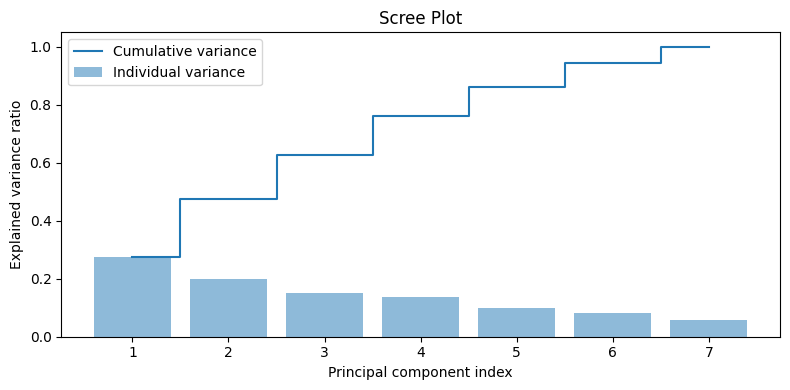

In [74]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('pca_variance.png')

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(X.columns))], 
    index=X.columns
)
print("PCA Loadings (Correlation between features and components):")
print(loadings.iloc[:, :3]) 

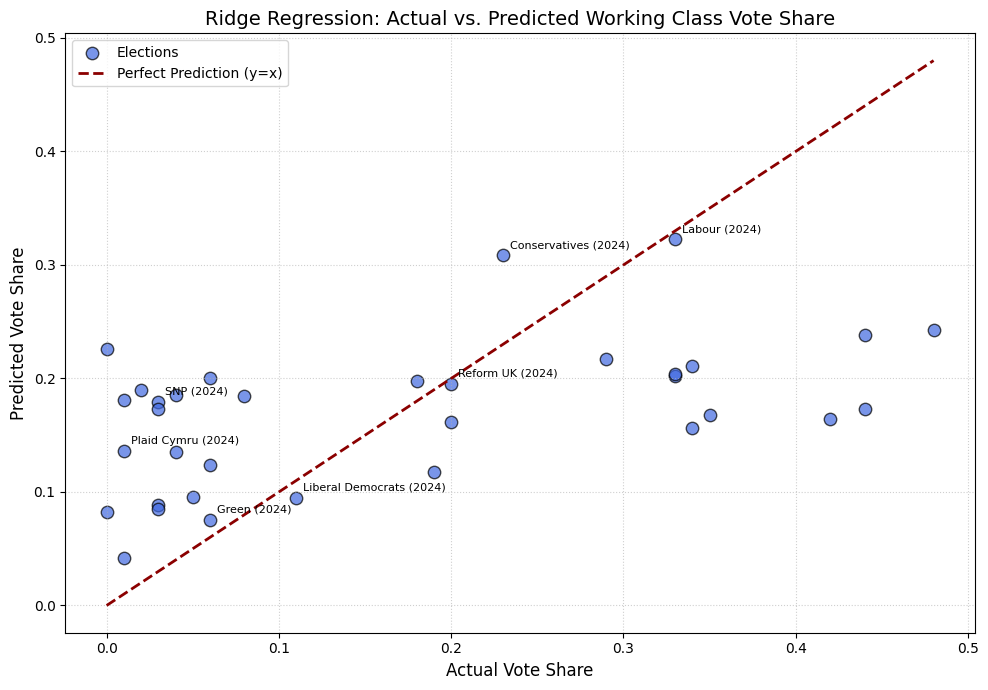

In [76]:
import matplotlib.pyplot as plt
import numpy as np

y_pred = ridge.predict(X_scaled)

plt.figure(figsize=(10, 7))

plt.scatter(y, y_pred, color='royalblue', edgecolors='black', s=80, alpha=0.7, label='Elections')

limits = [min(min(y), min(y_pred)), max(max(y), max(y_pred))]
plt.plot(limits, limits, color='darkred', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

for i in range(len(y)):
    if full_df.iloc[i]['election_year'] == 2024:
        label = f"{full_df.iloc[i]['party']} ({full_df.iloc[i]['election_year']})"
        plt.annotate(label, (y.iloc[i], y_pred[i]), 
                     textcoords="offset points", xytext=(5,5), ha='left', fontsize=8)


plt.title('Ridge Regression: Actual vs. Predicted Working Class Vote Share', fontsize=14)
plt.xlabel('Actual Vote Share', fontsize=12)
plt.ylabel('Predicted Vote Share', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('actual_vs_predicted_votes.png')
plt.show()

In [72]:
y

0     0.03
1     0.29
2     0.34
3     0.33
4     0.44
5     0.48
6     0.23
7     0.03
8     0.01
9     0.02
10    0.06
11    0.44
12    0.35
13    0.34
14    0.42
15    0.33
16    0.33
17    0.19
18    0.20
19    0.06
20    0.06
21    0.08
22    0.11
23    0.01
24    0.00
25    0.00
26    0.01
27    0.20
28    0.05
29    0.04
30    0.04
31    0.03
32    0.18
33    0.03
Name: working_class_vote_share, dtype: float64

In [143]:
X_with_const = sm.add_constant(X_scaled)
model = sm.OLS(y, X_with_const).fit()

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     working_class_vote_share   R-squared:                       0.267
Model:                                  OLS   Adj. R-squared:                  0.070
Method:                       Least Squares   F-statistic:                     1.353
Date:                      Mon, 27 Apr 2026   Prob (F-statistic):              0.266
Time:                              05:57:00   Log-Likelihood:                 20.289
No. Observations:                        34   AIC:                            -24.58
Df Residuals:                            26   BIC:                            -12.37
Df Model:                                 7                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [145]:
lasso = LassoCV(cv=5).fit(X_scaled, y)

print(lasso.coef_)

[ 0.04081425  0.02656337  0.02712092 -0.06213314 -0.01018599  0.00723136
 -0.01135883]


In [147]:
corr = pd.DataFrame(X_scaled, columns=X.columns).corr()
corr

,no_debates,Health_prop_words,Macroeconomics_prop_words,Social_Welfare_prop_words,Immigration_net_stance,Low_Income_Assistance_net_stance,Taxation_net_stance
no_debates,1.000000,0.360357,-0.147055,-0.142858,0.081331,0.027163,0.121385
Health_prop_words,0.360357,1.000000,-0.037883,0.011612,-0.166033,-0.051576,-0.005222
Macroeconomics_prop_words,-0.147055,-0.037883,1.000000,0.527894,-0.284827,-0.088542,-0.297230
Social_Welfare_prop_words,-0.142858,0.011612,0.527894,1.000000,-0.230660,-0.058148,-0.043431
Immigration_net_stance,0.081331,-0.166033,-0.284827,-0.230660,1.000000,0.286834,0.110619
Low_Income_Assistance_net_stance,0.027163,-0.051576,-0.088542,-0.058148,0.286834,1.000000,0.066289
Taxation_net_stance,0.121385,-0.005222,-0.297230,-0.043431,0.110619,0.066289,1.000000


In [160]:
X_reduced = X_scaled[:, [3, 4, 6]]
X_with_const = sm.add_constant(X_reduced)
model = sm.OLS(y, X_with_const).fit()

print(model.summary())

                               OLS Regression Results                               
Dep. Variable:     working_class_vote_share   R-squared:                       0.125
Model:                                  OLS   Adj. R-squared:                  0.038
Method:                       Least Squares   F-statistic:                     1.431
Date:                      Mon, 27 Apr 2026   Prob (F-statistic):              0.253
Time:                              06:18:26   Log-Likelihood:                 17.282
No. Observations:                        34   AIC:                            -26.56
Df Residuals:                            30   BIC:                            -20.46
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [158]:
ridge = RidgeCV(cv=5).fit(X_scaled, y)
ridge.coef_

array([ 0.03306992,  0.02241644,  0.0125888 , -0.04249705, -0.00715915,
        0.00482113, -0.01092279])